In [20]:
import sys, os, json
import mne, sklearn, wandb
import numpy as np
import pandas as pd

from scipy.interpolate import interp1d
from nilearn import datasets, image, masking, plotting
from nilearn.input_data import NiftiLabelsMasker

from IPython.display import HTML
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import animation, rc
from matplotlib.animation import FuncAnimation
import seaborn as sns
from nilearn.plotting import plot_anat

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, TensorDataset
from torch.utils.data import DataLoader, Subset

from pytorch_model_summary import summary

In [10]:
%load_ext autoreload
# %reload_ext autoreload
%autoreload 2
sys.path.insert(1, os.path.realpath(os.path.pardir))

import get_datasets
import preproc
import torch_dataset
import train_utils
import inference
import autoencoder_arch

In [ ]:
print(torch.cuda.is_available(), torch.cuda.device_count())
torch.cuda.set_device(0)

In [13]:
config = dict(  
                dataset_name = 'CWL_raw',
                patients = ['trio1'],
                fps = 1000,
                new_fps = 100, 
                crop_start = 5,
                freqs = [-1], 
    
                n_channels = 30, # 63 
                n_roi = 8,
                
                bold_delay = 6,
                to_many = True,
                random_subsample = True,
                sample_per_epoch = 512, 
                WINDOW_SIZE = 2048,
                    
                optimizer='adamW',
                lr=3e-4,
                weight_decay=3e-4, 
                batch_size=16, 
                    
                mse_weight = 1,
                corr_weight = 0,
                
                preproc_type = 'dB_log',
                loss_function = 'corr', 
                model_type = 'Best_AE_Artur_Multi_Head'
                )


hp_autoencoder = dict(n_electrodes=config['n_channels'],
                      n_freqs = len(config['freqs']),
                      n_channels_out = config['n_roi'],

                     channels = [128, 128, 128, 128], 
                     kernel_sizes=[5, 5, 3],
                     strides=[8, 8, 4], 
                     dilation=[1, 1, 1], 
                     decoder_reduce=4, 
                     hidden_channels = 16,
                     )


config = {**hp_autoencoder, **config}

params_train = {'batch_size': config['batch_size'],
                'shuffle': True,
                'num_workers': 0}

params_val = {'batch_size': config['batch_size'],
              'shuffle': False}

In [15]:
   
labels_roi = ['Left Pallidum',
                 'Left Caudate',
                 'Left Putamen',
                 'Left Accumbens',

                 'Right Pallidum',
                 'Right Caudate',
                 'Right Putamen',
                 'Right Accumbens']

In [16]:
path_to_dataset = 'Dataset'
dataset_name = 'CWL'
remove_confounds = True

for patient in config['patients']:
    df_eeg_cwl_raw, df_fmri_cwl_raw, labels_roi_17 = get_datasets.download_cwl_dataset(patient, path_to_dataset, 
                                                                        remove_confounds=remove_confounds,
                                                                        verbose=True)
    print("EEG data before interpolate",df_eeg_cwl_raw.shape)
    print("fMRI data before interpolate",df_fmri_cwl_raw.shape)
    df_eeg_cwl, df_fmri_cwl, fps = get_datasets.interpolate_df_eeg_fmri(df_eeg_cwl_raw, df_fmri_cwl_raw)
    print("EEG data after interpolate",df_eeg_cwl.shape)
    print("fMRI data after interpolate",df_fmri_cwl.shape)
    
    
    config['fps'] = fps
    print('Original FPS', config['fps']) 
    
    eeg_np = df_eeg_cwl.drop(['time'], axis=1).to_numpy().T
    fmri_np = df_fmri_cwl.drop(['time'], axis=1).to_numpy().T
    
    
    eeg_np = preproc.low_level_preproc_eeg(eeg_np, fps)
    
    data = {'eeg': eeg_np, 
            'fmri': fmri_np}

ALL path:  Dataset/trio1/CWL_Data/eeg/in-scan/trio1_mrcorrected_eoec_in-scan_hpump-off.set Dataset/trio1/CWL_Data/mri/epi_normalized/rwatrio1_eoec_in-scan_hpump-off.nii Dataset/trio1/CWL_Data/mri/epi_motionparams/rp_atrio1_eoec_in-scan_hpump-off.txt


/notebooks/BEIRA/get_datasets.py:131: RuntimeWarning: Data will be preloaded. preload=False or a string preload is not supported when the data is stored in the .set file
  raw = mne.io.read_raw_eeglab(eeg_path_set_file)
/notebooks/BEIRA/get_datasets.py:131: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(eeg_path_set_file)
/notebooks/BEIRA/get_datasets.py:87: UserWarning: 'labels' must be a list. Got: <class 'str'>
  masker_global_signal = NiftiLabelsMasker(mask, 'global_signal',
/notebooks/BEIRA/get_datasets.py:87: UserWarning: Mismatch between the number of provided labels (13) and the number of regions in provided label image (2).
  masker_global_signal = NiftiLabelsMasker(mask, 'global_signal',
/usr/local/lib/python3.11/dist-packages/nilearn/maskers/base_masker.py:253: UserWarning: Mismatch between the number of provided labels (13) and the number of regio


Added README.md to /root/nilearn_data


Dataset created in /root/nilearn_data/fsl



 ...done. (0 seconds, 0 min)
Extracting data from /root/nilearn_data/fsl/8a6a179c4b7672ec60913c596b129eff/HarvardOxford.tgz..... done.
/notebooks/BEIRA/get_datasets.py:108: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  motion_confound = pd.read_csv(motion_params_path, sep = '  ', header=None)


Dimension of our EEG data:  (303601, 31)
Dimension of our fMRi data:  (61, 72, 61, 146)
Dimension of our fMRi Roi data:  (143, 18)
fMRI info :  1.95
RoI:  ['Left Lateral Ventricle', 'Left Thalamus', 'Left Caudate', 'Left Putamen', 'Left Pallidum', 'Brain-Stem', 'Left Hippocampus', 'Left Amygdala', 'Left Accumbens', 'Right Lateral Ventricle', 'Right Thalamus', 'Right Caudate', 'Right Putamen', 'Right Pallidum', 'Right Hippocampus', 'Right Amygdala', 'Right Accumbens', 'time']
EEG data before interpolate (303601, 31)
fMRI data before interpolate (143, 18)
EEG time range: 0.0 to 303600.0
fMRI time range: 23322.0 to 300223.0
EEG data after interpolate (276902, 31)
fMRI data after interpolate (276902, 18)
Original FPS 1000
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transit

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.3s


Setting up band-pass filter from 1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 3301 samples (3.301 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s


In [23]:
channel_names = df_eeg_cwl_raw.columns.tolist()

channel_names = [col for col in channel_names if col != 'time']

print("EEG Channel Names:", channel_names)

EEG Channel Names: ['F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'PO3', 'PO4', 'FC5', 'FC6', 'CP5', 'CP6', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'TP9', 'TP10', 'PO9', 'PO10', 'Fpz', 'Fz', 'Cz', 'Pz', 'POz', 'Oz', 'Iz', 'AFz']


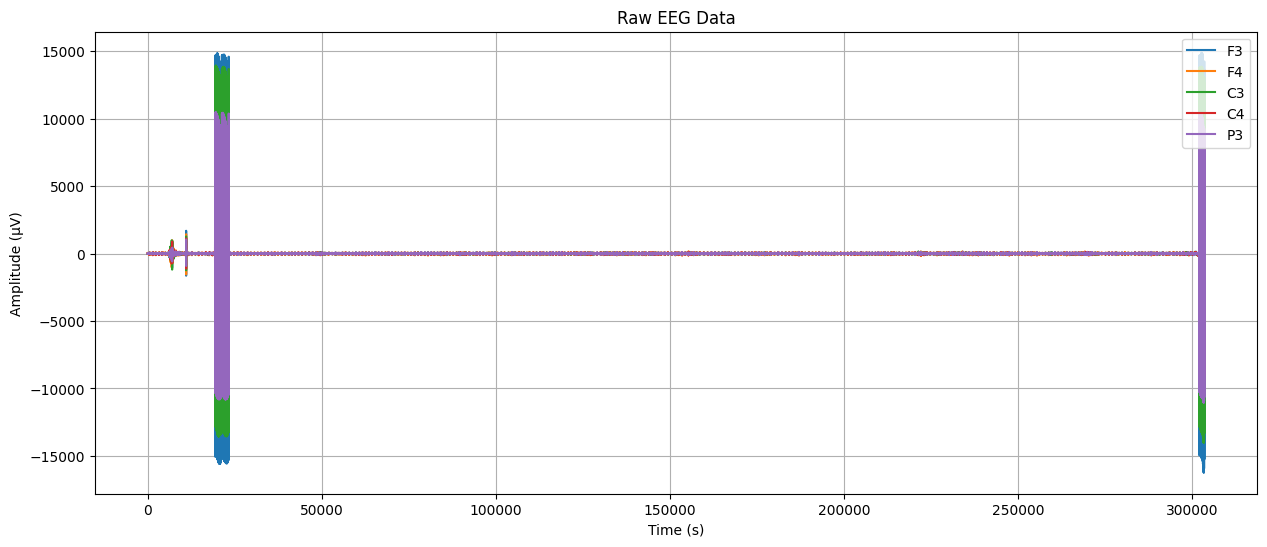

In [30]:
channels_to_plot = ['F3', 'F4', 'C3', 'C4', 'P3']

channel_indices = [df_eeg_cwl.columns.get_loc(channel) for channel in channels_to_plot]

plt.figure(figsize=(15, 6))
for i, channel_idx in enumerate(channel_indices):
    plt.plot(df_eeg_cwl_raw['time'], df_eeg_cwl_raw.iloc[:, channel_idx], label=channels_to_plot[i])
    
plt.title('Raw EEG Data')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

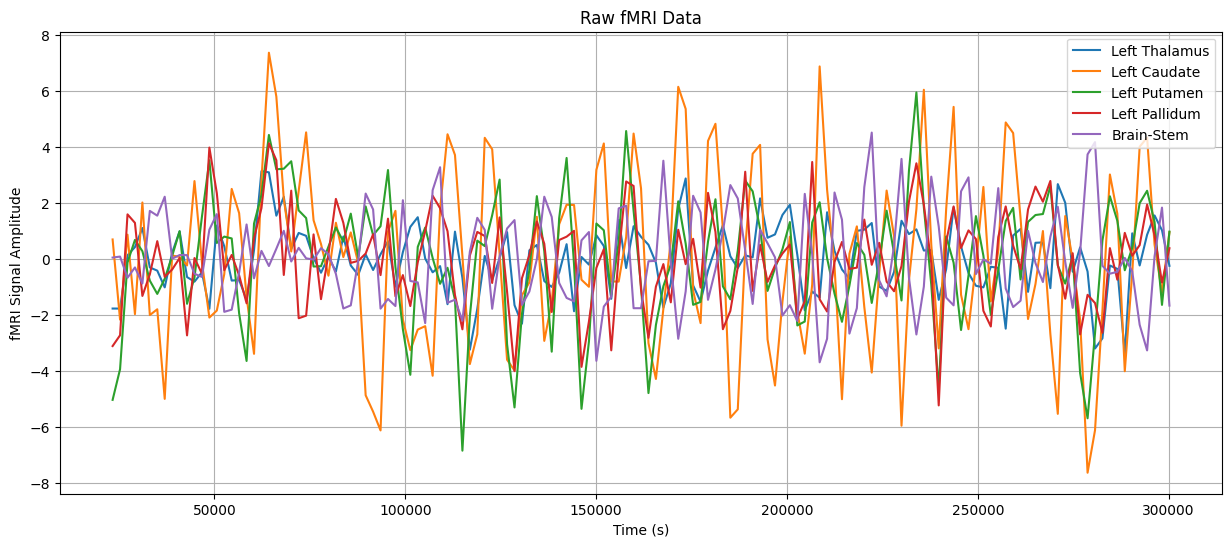

In [27]:
rois_to_plot = df_fmri_cwl_raw.columns[1:6]

plt.figure(figsize=(15, 6))

for roi in rois_to_plot:
    plt.plot(df_fmri_cwl_raw['time'], df_fmri_cwl_raw[roi], label=roi)

plt.title('Raw fMRI Data')
plt.xlabel('Time (s)')
plt.ylabel('fMRI Signal Amplitude')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

In [17]:
df_eeg_cwl_raw['time'], df_fmri_cwl_raw['time']

(0              0.0
 1              1.0
 2              2.0
 3              3.0
 4              4.0
             ...   
 303596    303596.0
 303597    303597.0
 303598    303598.0
 303599    303599.0
 303600    303600.0
 Name: time, Length: 303601, dtype: float64,
 0       23322.0
 1       25272.0
 2       27222.0
 3       29172.0
 4       31122.0
          ...   
 138    292423.0
 139    294373.0
 140    296323.0
 141    298273.0
 142    300223.0
 Name: time, Length: 143, dtype: float64)

In [18]:

eeg, fmri = data['eeg'], data['fmri']
df = pd.DataFrame(data = fmri.T, columns=labels_roi_17)
df_filter = df[labels_roi]
fmri = df_filter.to_numpy().T

train_crop = config['crop_start']*config['fps']
eeg, fmri = eeg[..., train_crop:], fmri[..., train_crop:]

eeg = eeg / np.std(eeg)
fmri, fmri_means_stds = preproc.normalize_data(fmri)

test_time = int(60*config['fps'])
train_dataset_prep = (eeg[..., :-test_time], fmri[..., :-test_time])
test_dataset_prep = (eeg[..., -test_time:], fmri[..., -test_time:])

ds_factor = config['fps']/config['new_fps']
train_dataset_prep = preproc.downsample_dataset(train_dataset_prep, factor = ds_factor)
test_dataset_prep = preproc.downsample_dataset(test_dataset_prep, factor = ds_factor)



train_dataset_prep = preproc.bold_time_delay_align(train_dataset_prep, 
                                                   config['new_fps'],
                                                   config['bold_delay'])
test_dataset_prep = preproc.bold_time_delay_align(test_dataset_prep, 
                                                  config['new_fps'],
                                                  config['bold_delay'])


print('Size of train dataset:', train_dataset_prep[0].shape, train_dataset_prep[1].shape)
print('Size of test dataset:', test_dataset_prep[0].shape, test_dataset_prep[1].shape)


torch_dataset_train = torch_dataset.CreateDataset_eeg_fmri(train_dataset_prep, 
                                                            random_sample=config['random_subsample'], 
                                                            sample_per_epoch=config['sample_per_epoch'], 
                                                            to_many=config['to_many'], 
                                                            window_size = config['WINDOW_SIZE'])

torch_dataset_test = torch_dataset.CreateDataset_eeg_fmri(test_dataset_prep, 
                                                            random_sample=False, 
                                                            sample_per_epoch=None, 
                                                            to_many=config['to_many'], 
                                                            window_size = config['WINDOW_SIZE'])
print('Size of test dataset:', len(torch_dataset_test))

torch_dataset_test = Subset(torch_dataset_test, np.arange(len(torch_dataset_test))[::100])

train_loader = torch.utils.data.DataLoader(torch_dataset_train, **params_train)
val_loader = torch.utils.data.DataLoader(torch_dataset_test, **params_val)




Size of train dataset: (30, 20590) (8, 20590)
Size of test dataset: (30, 5400) (8, 5400)
Size of test dataset: 3351


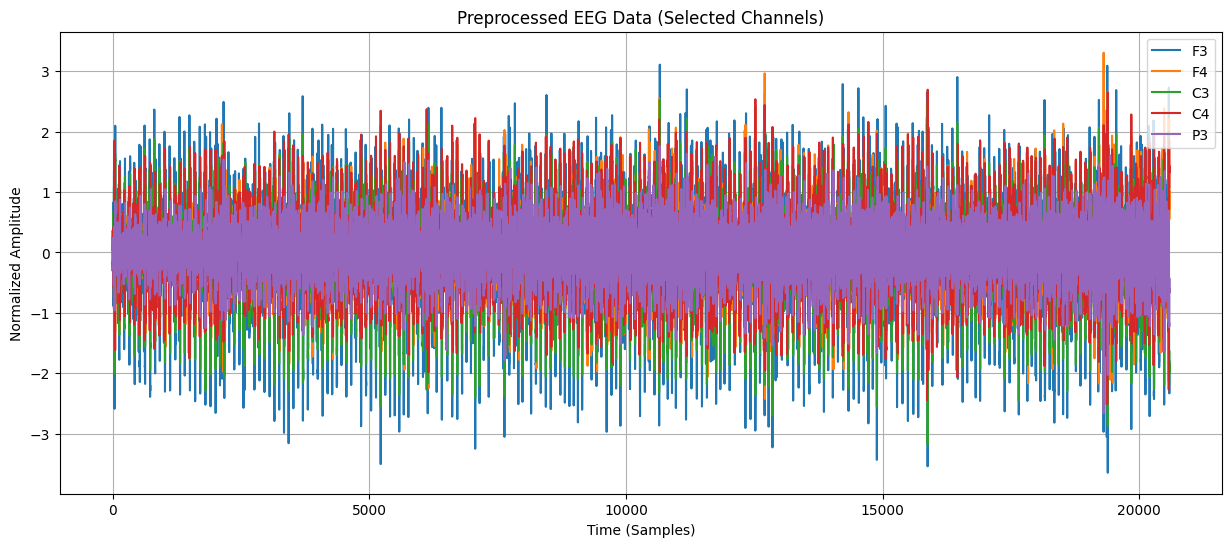

In [32]:
channel_names = df_eeg_cwl_raw.columns.tolist()

channels_to_plot = ['F3', 'F4', 'C3', 'C4', 'P3']

channel_indices = [channel_names.index(ch) for ch in channels_to_plot if ch in channel_names]

plt.figure(figsize=(15, 6))

for i, channel_idx in enumerate(channel_indices):
    plt.plot(np.arange(train_dataset_prep[0].shape[1]), train_dataset_prep[0][channel_idx, :], label=channels_to_plot[i])

plt.title('Preprocessed EEG Data (Selected Channels)')
plt.xlabel('Time (Samples)')
plt.ylabel('Normalized Amplitude')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

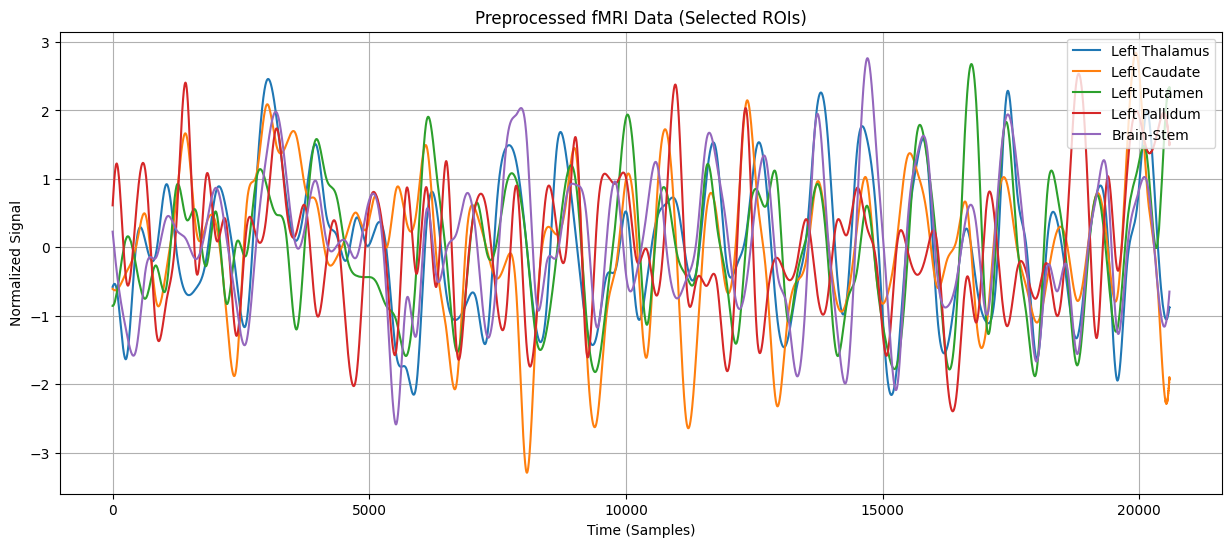

In [33]:
roi_names = df_fmri_cwl_raw.columns.tolist()

rois_to_plot = ['Left Thalamus', 'Left Caudate', 'Left Putamen', 'Left Pallidum', 'Brain-Stem']

roi_indices = [roi_names.index(roi) for roi in rois_to_plot if roi in roi_names]

plt.figure(figsize=(15, 6))

for i, roi_idx in enumerate(roi_indices):
    plt.plot(np.arange(train_dataset_prep[1].shape[1]), train_dataset_prep[1][roi_idx, :], label=rois_to_plot[i])

plt.title('Preprocessed fMRI Data')
plt.xlabel('Time (Samples)')
plt.ylabel('Normalized Signal')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

In [9]:
model = autoencoder_arch.AutoEncoder1D_Artur_MultiHead(hp_autoencoder)

print(summary(model, torch.zeros(4, config['n_channels'],
                                 config['WINDOW_SIZE']), show_input=False))


-----------------------------------------------------------------------------
            Layer (type)        Output Shape         Param #     Tr. Param #
   AutoEncoder1D_Artur-1        [4, 1, 2048]         245,057         245,057
   AutoEncoder1D_Artur-2        [4, 1, 2048]         245,057         245,057
   AutoEncoder1D_Artur-3        [4, 1, 2048]         245,057         245,057
   AutoEncoder1D_Artur-4        [4, 1, 2048]         245,057         245,057
   AutoEncoder1D_Artur-5        [4, 1, 2048]         245,057         245,057
   AutoEncoder1D_Artur-6        [4, 1, 2048]         245,057         245,057
   AutoEncoder1D_Artur-7        [4, 1, 2048]         245,057         245,057
   AutoEncoder1D_Artur-8        [4, 1, 2048]         245,057         245,057
Total params: 1,960,456
Trainable params: 1,960,456
Non-trainable params: 0
-----------------------------------------------------------------------------


# Model training

In [ ]:
n_runs = 3

for i in range(n_runs):
    
    model = autoencoder_arch.AutoEncoder1D_Artur_MultiHead(hp_autoencoder)

    loss_func = train_utils.make_complex_loss_function(mse_weight = config['mse_weight'], 
                                                       corr_weight = config['corr_weight'],
                                                       manifold_weight = 0,
                                                       bound=1)
    train_step = train_utils.train_step

    optimizer = optim.AdamW(model.parameters(), 
                       lr=config['lr'], 
                       weight_decay=config['weight_decay'])
    
    
    parameters = {
        'EPOCHS': 500,
        'model': model, 
        'train_loader': train_loader, 
        'val_loader': val_loader, 
        'loss_function': loss_func,
        'train_step': train_step,
        'optimizer': optimizer, 
        'device': 'cpu', 
        'raw_test_data': test_dataset_prep,
        'show_info': 20, 
        'num_losses': 5,
        'labels': labels_roi,
        'inference_function': inference.model_inference_function, 
        'to_many': config['to_many']
    }



    path_to_save_wandb = 'common/koval_alvi/Checkpoints/wandb_brain'
    
    
    with wandb.init(project="eeg_fmri", config=config, save_code=True):
        
        wandb.define_metric("val/corr_mean", summary="max")

        if i == 0: 
            exp_name = wandb.run.name
        
        wandb.run.name = exp_name +'_run_' + str(i)
        
        print(config)
        print(parameters['model'])
        print(summary(model, torch.zeros(4, config['n_channels'], config['WINDOW_SIZE']), show_input=False))
        
        model = train_utils.wanb_train_regression(**parameters)
        

In [ ]:
pip install wandb --upgrade

# 